## TASK 2

**Choice of dataset**: [Kaggle: Simpsons Faces](https://www.kaggle.com/datasets/kostastokis/simpsons-faces)

The dataset contains 9877 Simpsons faces, extracted from seasons 25-28. All images are 200x200 pixels, each centered on a single face.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np


In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        # ==========================================
        # ENCODER: Compressing 200x200 -> 5x5
        # ==========================================

        # NOTE: we don't use Max Pooling like in classical CNN and use Strided Convolutions instead
        # stride = 2 means the convolutional filter jumps 2 pixels at a time as it slides across the image
        # Max Pooling throws away data (it only keeps the highest pixel value in a grid). 
        # By using a stride of 2, the network learns its own optimal way to downsample the image.
        self.encoder = nn.Sequential(
            # LAYER 1
            # in_channels=3: We start with 3 color channels (Red, Green, Blue).
            # out_channels=32: The network applies 32 unique filters to find basic edges/colors.
            # Since we want to cut the image size in half, we need stride=2, padding=1 and kernel_size=4
            # Spatial Math: (200 - 4 + 2*1) / 2 + 1 = 100
            # Image size drops from 200x200 -> 100x100
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 2
            # Image size drops from 100x100 -> 50x50
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 3
            # Image size drops from 50x50 -> 25x25
            # NOTE: We have hit an odd number (25). A standard stride=2 will break here.
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 4
            # To fix the 25x25 problem, we use a kernel of 5 and a stride of 5, with no padding.
            # This means the filter jumps 5 pixels at a time, fitting perfectly into 25 exactly 5 times.
            # Spatial Math: (25 - 5 + 0) / 5 + 1 = 5
            # Image size drops from 25x25 -> 5x5
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=5, stride=5, padding=0),
            nn.ReLU(),
            
            # Flatten takes the 3D tensor (256 channels, 5x5 grid) and unrolls it into a 1D list.
            nn.Flatten()
        )
        
        # ==========================================
        # THE BOTTLENECK (Latent Space)
        # ==========================================
        # Flattened size: 256 channels * 5 width * 5 height = 6400
        #
        # Hardware Note: Crushing the image down to 5x5 is vital for memory management. 
        # If we stopped at 50x50, the flattened size would be 160,000.
        
        # fc_mu predicts the "center" of the probability distribution for the image.
        self.fc_mu = nn.Linear(in_features=6400, out_features=latent_dim)
        
        # fc_logvar predicts the "spread" or variance of that distribution.
        self.fc_logvar = nn.Linear(in_features=6400, out_features=latent_dim)
        
        # ==========================================
        # DECODER: Expanding 5x5 -> 200x200
        # ==========================================
        
        # First, we take the sampled latent vector and blow it back up 
        # to 6400 numbers so we can un-flatten it into our 5x5 grid.
        self.fc_dec = nn.Linear(in_features=latent_dim, out_features=6400)
        
        # The decoder is the exact inverse of the encoder. We use ConvTranspose2d, 
        # which effectively "paints" pixels outward rather than compressing them inward.
        self.decoder = nn.Sequential(
            
            # LAYER 4 (Reversed)
            # We perfectly reverse the parameters of Encoder Layer 4 (kernel=5, stride=5).
            # Image size grows from 5x5 -> 25x25
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=5, stride=5, padding=0),
            nn.ReLU(),
            
            # LAYER 3 (Reversed)
            # Image size grows from 25x25 -> 50x50
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 2 (Reversed)
            # Image size grows from 50x50 -> 100x100
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 1 (Reversed)
            # out_channels=3: The very last layer MUST output 3 channels to recreate the RGB image.
            # Image size grows from 100x100 -> 200x200
            nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1),
            
            # Since pixel values are traditionally normalized between 0 and 1, this ensures 
            # the network doesn't generate "impossible" pixel colors.
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, logvar):
        """
        The reparameterization trick allows us to backpropagate through the random sampling.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        x_enc = self.encoder(x)
        
        # Get latent parameters
        mu = self.fc_mu(x_enc)
        logvar = self.fc_logvar(x_enc)
        
        # Sample from latent space
        z = self.reparameterize(mu, logvar)
        
        # Decode
        x_dec = self.fc_dec(z)
        x_dec = x_dec.view(-1, 256, 5, 5) # Unflatten back to feature maps
        reconstruction = self.decoder(x_dec)
        
        return reconstruction, mu, logvar

def vae_loss(reconstruction, original, mu, logvar):
    """
    VAE Loss = Reconstruction Loss + Kullback-Leibler Divergence
    """
    # Measure how well the image was reconstructed (MSE or BCE)
    recon_loss = F.mse_loss(reconstruction, original, reduction='sum')
    
    # Measure how closely the latent space matches a standard normal distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + kld_loss

    return total_loss, recon_loss, kld_loss

In [4]:
# HYPERPARAMETERS
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-4
LATENT_DIM = 128

In [5]:
DEVICE = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {DEVICE}")

Device used: cuda:2


In [6]:
# Define transformations specific to our architecture
transform = transforms.Compose([
    transforms.Resize((200, 200)), # Ensure all images are 200x200
    transforms.ToTensor() # Go from (200, 200, 3) to (3, 200, 200) and convert to [0, 1] scale by dividing all pixel values by 255.0
])

In [7]:
# Load Dataset
dataset = datasets.ImageFolder(root="./simpsons", transform=transform)

# Train/Val split
total_size = len(dataset)
val_size = int(0.2 * total_size)
train_size = total_size - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# model_vae initialization
model_vae = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=LEARNING_RATE)

history_vae = {
    'train_loss': [], 'val_loss': [], 
    'train_recon': [], 'train_kl': []
}

In [9]:
print("Starting Training/Validation")

for epoch in range(EPOCHS):
    model_vae.train()
    train_loss_sum = 0
    train_recon_sum = 0
    train_kl_sum = 0

    # =========================
    # TRAINING PHASE
    # =========================
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer_vae.zero_grad()
        
        reconstruction, mu, logvar = model_vae(images)
        loss, recon, kl = vae_loss(reconstruction, images, mu, logvar)
        
        loss.backward()
        optimizer_vae.step()
        
        train_loss_sum += loss.item()
        train_recon_sum += recon.item()
        train_kl_sum += kl.item()

    # =========================
    # VALIDATION PHASE
    # =========================
    model_vae.eval()
    val_loss_sum = 0
    
    with torch.no_grad():
        for val_images, _ in val_loader:
            val_images = val_images.to(DEVICE)
            reconstruction, mu, logvar = model_vae(val_images)
            loss, _, _ = vae_loss(reconstruction, val_images, mu, logvar)
            val_loss_sum += loss.item()
            
    # Calculate averages for the epoch
    avg_train_loss = train_loss_sum / len(train_loader.dataset)
    avg_train_recon = train_recon_sum / len(train_loader.dataset)
    avg_train_kl = train_kl_sum / len(train_loader.dataset)
    avg_val_loss = val_loss_sum / len(val_loader.dataset)
    
    # Save to history_vae
    history_vae['train_loss'].append(avg_train_loss)
    history_vae['train_recon'].append(avg_train_recon)
    history_vae['train_kl'].append(avg_train_kl)
    history_vae['val_loss'].append(avg_val_loss)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Starting Training/Validation
Epoch 1 | Train Loss: 8717.8301 | Val Loss: 6861.8314
Epoch 2 | Train Loss: 6488.2643 | Val Loss: 5945.3369
Epoch 3 | Train Loss: 5306.6875 | Val Loss: 4768.7892
Epoch 4 | Train Loss: 4330.0051 | Val Loss: 4099.9357
Epoch 5 | Train Loss: 3920.9786 | Val Loss: 3821.5945
Epoch 6 | Train Loss: 3724.9009 | Val Loss: 3668.4028
Epoch 7 | Train Loss: 3584.5037 | Val Loss: 3570.6459
Epoch 8 | Train Loss: 3477.6953 | Val Loss: 3480.7528
Epoch 9 | Train Loss: 3397.9212 | Val Loss: 3386.7393
Epoch 10 | Train Loss: 3317.1138 | Val Loss: 3357.2669


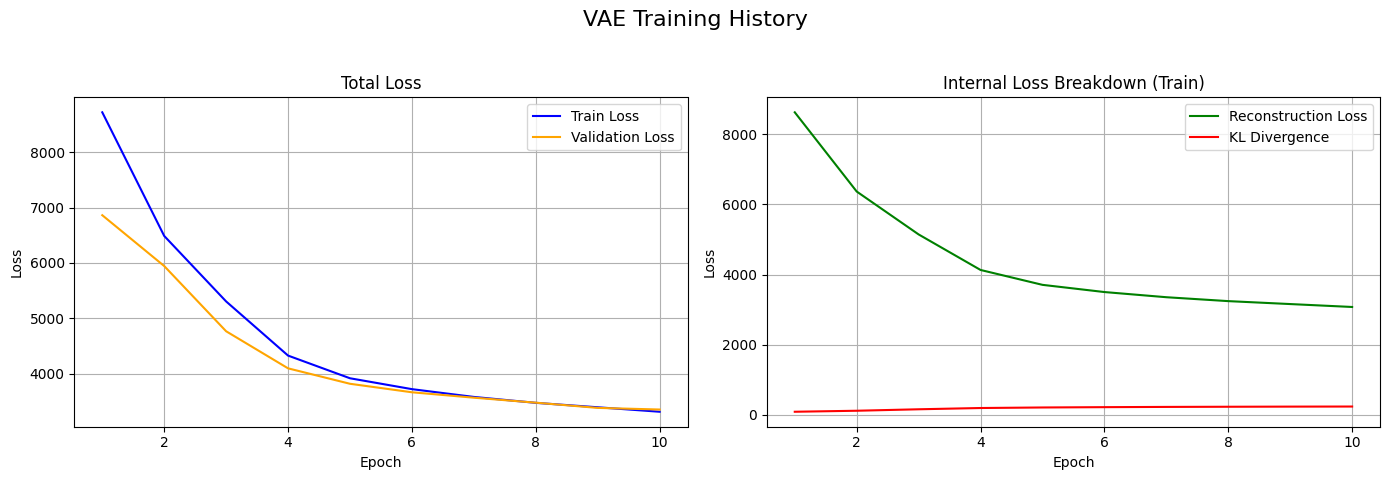

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VAE Training History", fontsize=16)

# Plot 1: Training vs Validation Total Loss
axs[0].plot(range(1, EPOCHS+1), history_vae['train_loss'], label='Train Loss', color='blue')
axs[0].plot(range(1, EPOCHS+1), history_vae['val_loss'], label='Validation Loss', color='orange')
axs[0].set_title('Total Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot 2: VAE Internal Breakdown (Recon vs KL)
axs[1].plot(range(1, EPOCHS+1), history_vae['train_recon'], label='Reconstruction Loss', color='green')
axs[1].plot(range(1, EPOCHS+1), history_vae['train_kl'], label='KL Divergence', color='red')
axs[1].set_title('Internal Loss Breakdown (Train)')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

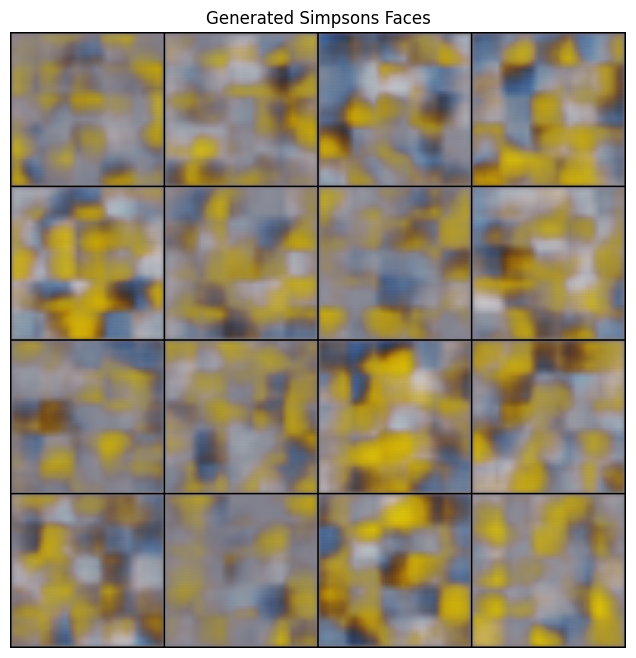

In [11]:
# Generate 16 images
num_images = 16
model_vae.eval()

with torch.no_grad():
    # Sample random noise from a standard normal distribution
    # Shape: [num_images, latent_dim]
    random_latent_vectors = torch.randn(num_images, LATENT_DIM).to(DEVICE)
    
    # Pass the noise through the decoder's linear layer
    x_dec = model_vae.fc_dec(random_latent_vectors)
    
    # Reshape to match the expected 256 channels of 5x5 grids
    x_dec = x_dec.view(-1, 256, 5, 5)
    
    # Decode into images
    generated_images = model_vae.decoder(x_dec)
    
# Move images to CPU for plotting
generated_images = generated_images.cpu()

# Create a grid of images
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Simpsons Faces")

# vutils.make_grid automatically handles the padding and arranging
grid = vutils.make_grid(generated_images, nrow=4, padding=2, normalize=False)

# PyTorch uses (Channels, Height, Width) but matplotlib needs (Height, Width, Channels)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()

### Results Analysis

* Training and Validation loss both dropped smoothly and stayed perfectly aligned. There is no sign of overfitting.
* Reconstruction Loss plummeted while KL Divergence slightly rose. This is the ideal "tug-of-war". 
* The generated images remain blurry. More epochs would refine the colors, but VAEs are mathematically biased toward blurriness. 

To get better images, we must transition to a GAN, where a Discriminator will actively penalize blurry outputs. 